In [3]:
import os
print(os.getcwd())

C:\Users\Sakshi\customer-churn-prediction


In [4]:
# Remove the '../' because you are already in the main folder
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [5]:
import os

# List everything in the current directory
print("Current Location:", os.getcwd())
print("Files/Folders here:", os.listdir('.'))

# List everything inside the data folder
if os.path.exists('data'):
    print("Files inside data folder:", os.listdir('data'))
else:
    print("Cannot find 'data' folder from here!")

Current Location: C:\Users\Sakshi\customer-churn-prediction
Files/Folders here: ['.ipynb_checkpoints', 'app.py', 'data', 'models', 'notebooks', 'README.md', 'requirements.txt', 'Untitled.ipynb', 'visualizations']
Files inside data folder: ['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [6]:
import pandas as pd

# Load the data using the direct path from your current location
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Success check
print("Data loaded! Shape:", df.shape)
df.head()

Data loaded! Shape: (7043, 50)


,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Load data
# Use the filename that is actually in your folder
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 2. RENAME COLUMNS (Crucial Step for your 50-column version)
# This removes spaces and makes everything easier to type
df.columns = df.columns.str.replace(' ', '_')

# 3. Fix Numeric Column
# In your data, it's likely 'Total_Charges' or 'Total_Revenue'
df['Total_Charges'] = pd.to_numeric(df['Total_Charges'], errors='coerce')
df.dropna(subset=['Total_Charges'], inplace=True)

print("Dataset Shape:", df.shape)
print("\nFirst 2 rows (shortened):")
display(df.head(2))

FileNotFoundError: [Errno 2] No such file or directory: '../data/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [9]:
# Remove the '../'
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [10]:
import os

# Check if we are in the root or notebooks folder
if os.path.exists('data/WA_Fn-UseC_-Telco-Customer-Churn.csv'):
    path = 'data/WA_Fn-UseC_-Telco-Customer-Churn.csv'
else:
    path = '../data/WA_Fn-UseC_-Telco-Customer-Churn.csv'

df = pd.read_csv(path)
print("Data loaded successfully from:", path)

Data loaded successfully from: data/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [11]:
# Strip whitespace and replace spaces with underscores for easy coding
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

# Fix the Total_Charges / Total_Revenue numeric issue
# Check your column list; it might be 'Total_Charges' or 'Total_Revenue'
target_col = 'Total_Charges' if 'Total_Charges' in df.columns else 'Total_Revenue'

df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
df.dropna(subset=[target_col], inplace=True)

print(f"Cleaned columns. Data now has {df.shape[0]} rows.")

Cleaned columns. Data now has 7043 rows.


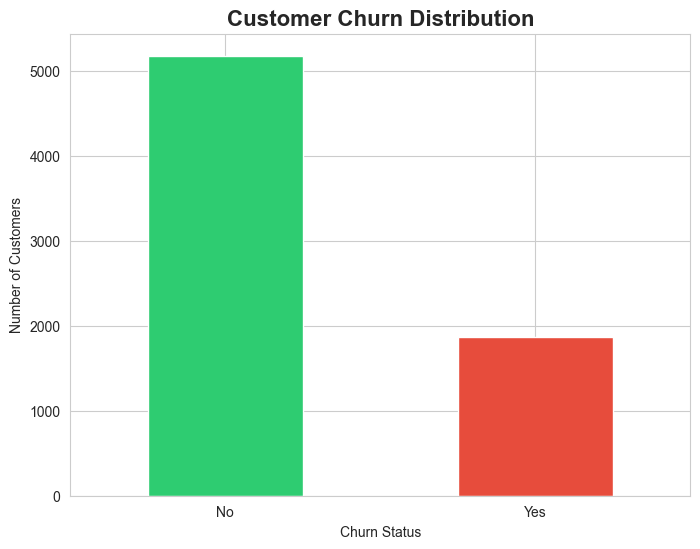

In [12]:
# Churn distribution
plt.figure(figsize=(8, 6))
df['Churn_Label'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Customer Churn Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

# Create the folder for visualizations if it doesn't exist
import os
if not os.path.exists('visualizations'):
    os.makedirs('visualizations')

plt.savefig('visualizations/churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show()